# **ASIGNACIÓN 1: Calibración de un sensor IoT**

Integrantes:
1. Fernando Quintana Gónzalez 2241359
2. Isabella María Ucrós Muñoz 2240675



#### **Bibliotecas**



In [1]:
import pandas as pd
import numpy as np
import sympy as sp
from sympy import *

import time
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
from google.colab import files
aploaded = files.upload()

Saving Datos_IoT.xlsx to Datos_IoT (3).xlsx


In [3]:
from google.colab import files
aploaded = files.upload()

Saving Datos_Estaciones_AMB.xlsx to Datos_Estaciones_AMB (2).xlsx


### **Datos originales**

In [4]:
data_IoT = pd.read_excel("Datos_IoT.xlsx")
data_ref = pd.read_excel("Datos_Estaciones_AMB.xlsx")
# Se leen los archivos .csv y excel


# DATOS IOT:
## Se convierte la columna de tiempo a una de tipo dateFecha
data_IoT["fecha_hora_med"] = pd.to_datetime(data_IoT["fecha_hora_med"], unit = 'ns')

## Se convierten los valores númericos (de las PMs) a numpy (valores numéricos)
valores_iot = data_IoT["PM2.5"].to_numpy()

## Renombrando las columnas:
data_IoT.rename(columns={"fecha_hora_med": "Fecha"}, inplace=True)


# DATOS REF (AMB): (pasos idénticos a los datos IoT)

data_ref["Date&Time"] =pd.to_datetime(data_ref["Date&Time"], errors = 'coerce', unit = 'ns')
data_ref["PM2.5"] = pd.to_numeric(data_ref["PM2.5"], errors="coerce")
data_ref.rename(columns={"Date&Time": "Fecha"}, inplace=True)

# Eliminando la zona horaria de ambos para que los permita comparar:
data_IoT['Fecha'] = pd.to_datetime(data_IoT['Fecha']).dt.tz_localize(None)
data_ref['Fecha'] = pd.to_datetime(data_ref['Fecha']).dt.tz_localize(None)

In [5]:
# Se eliminan las filas vacías:
data_IoT = data_IoT.dropna()
data_ref = data_ref.dropna()
data_ref = data_ref.dropna(subset = ['PM2.5'])

# Ordenando los datos por fecha
data_IoT = data_IoT.sort_values("Fecha")
data_ref = data_ref.sort_values("Fecha")

# Para que los índices de la visualización de la tabla se reinicien:
data_IoT = data_IoT.reset_index(drop=True)


In [6]:
data_IoT

,Fecha,PM2.5
0,2018-11-03 23:32:49.639,9.083333
1,2018-11-03 23:37:50.639,9.083333
2,2018-11-03 23:42:50.639,8.583334
3,2018-11-03 23:47:49.641,8.666667
4,2018-11-03 23:52:49.638,8.666666
...,...,...
5003,2019-09-01 00:02:50.912,6.166667
5004,2019-09-01 01:02:49.911,7.833333
5005,2019-09-01 02:02:49.912,5.416667
5006,2019-09-01 03:02:49.912,5.750000


In [7]:
data_ref

,Fecha,PM2.5
0,2018-10-01 00:00:00,6.4
1,2018-10-01 01:00:00,6.4
2,2018-10-01 02:00:00,6.7
3,2018-10-01 03:00:00,6.0
4,2018-10-01 04:00:00,7.3
...,...,...
8035,2019-08-31 19:00:00,20.4
8036,2019-08-31 20:00:00,18.7
8037,2019-08-31 21:00:00,22.8
8038,2019-08-31 22:00:00,25.2


In [8]:
data_ref.shape

(7086, 2)

In [9]:
data_IoT.shape

(5008, 2)

**Gráfica datos originales**

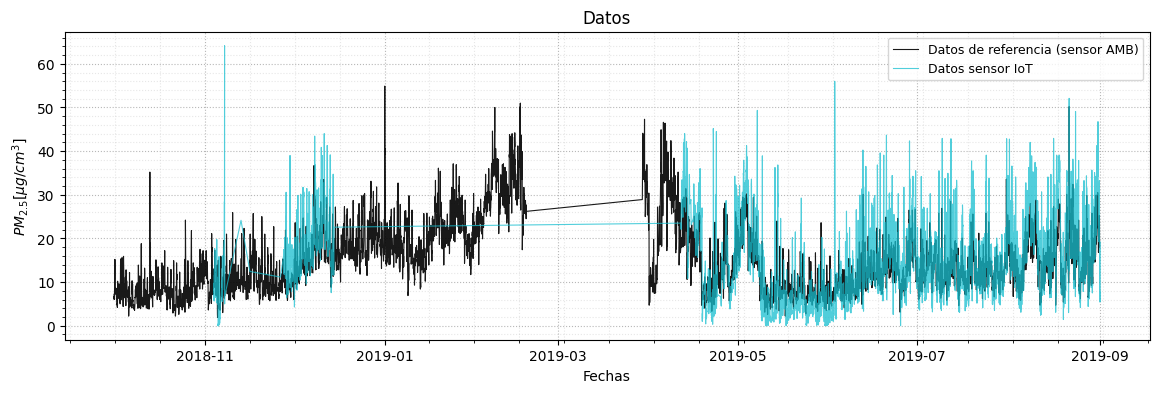

In [10]:
plt.figure(figsize = (14, 4))


plt.plot(data_ref['Fecha'],data_ref['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth = 0.8, color = "#000000", alpha = 0.9)
plt.plot(data_IoT['Fecha'],data_IoT['PM2.5'], label='Datos sensor IoT', linewidth = 0.8, color = "tab:cyan", alpha = 0.75)

# Configuración del gráfico:

plt.xlabel("Fechas")
plt.ylabel(r'$PM_{2.5}  [μg/cm^{3}]$')
plt.title("Datos")
plt.minorticks_on()
plt.legend(fontsize = 9)
plt.gca().set_axisbelow(True)
plt.grid(which='major', alpha=0.9, linestyle=':')
plt.grid(which='minor', alpha=0.3, linestyle=':')

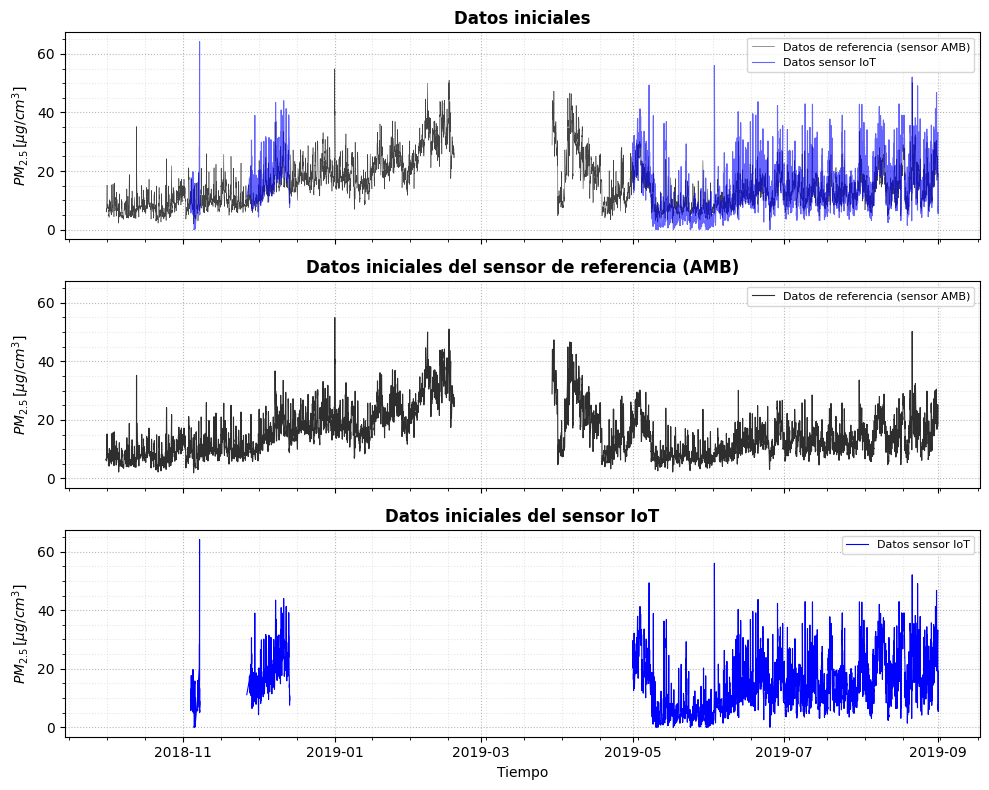

In [11]:
# Para graficar los datos de forma inicial, haremos subplots, para poder así mostrar la superposición de ambos datos pero también a ellos de forma
# individual para una mejor visualización
#### DIVIDIMOS LOS DATOS PARA QUE EL GRAFICO NO GRAFIQUE COMO CONSTANTES LAS DISCONTINUIDADES:
data_IoT1 = data_IoT[(data_IoT['Fecha'] >= '2018-11-01') & (data_IoT['Fecha'] <= '2018-11-07 16:04:21.129')].reset_index(drop=True)
data_IoT3 = data_IoT[(data_IoT['Fecha'] >= '2018-11-26 ') & (data_IoT['Fecha'] <= '2018-12-14')].reset_index(drop=True)
data_IoT2 = data_IoT[(data_IoT['Fecha'] >= '2019-05-01')].reset_index(drop=True)


data_ref1 = data_ref[(data_ref['Fecha'] <= '2019-02-18 4:00')].reset_index(drop=True)
data_ref2 = data_ref[(data_ref['Fecha'] >= '2019-03-29 14:00')].reset_index(drop=True)


####
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)

# SUPERPUESTOS
axs[0].plot(data_ref1['Fecha'], data_ref1['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth=0.4, color="#2E2E2E", alpha=0.9)
axs[0].plot(data_ref2['Fecha'], data_ref2['PM2.5'], linewidth=0.4, color="#2E2E2E", alpha=0.9)


axs[0].plot(data_IoT1['Fecha'], data_IoT1['PM2.5'], label='Datos sensor IoT', linewidth=0.8, color="blue", alpha=0.6)
axs[0].plot(data_IoT2['Fecha'], data_IoT2['PM2.5'], linewidth=0.8, color="blue", alpha=0.6)
axs[0].plot(data_IoT3['Fecha'], data_IoT3['PM2.5'], linewidth=0.8, color="blue", alpha=0.6)

axs[0].set_title("Datos iniciales", fontweight = 'bold')
axs[0].set_ylabel(r'$PM_{2.5}\,[\mu g/cm^{3}]$')
axs[0].minorticks_on()
axs[0].legend(fontsize=8)
axs[0].set_axisbelow(True)
axs[0].grid(which='major', alpha=0.9, linestyle=':')
axs[0].grid(which='minor', alpha=0.3, linestyle=':')

# REFERENCIA
axs[1].plot(data_ref1['Fecha'], data_ref1['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth=0.8, color="#2E2E2E")
axs[1].plot(data_ref2['Fecha'], data_ref2['PM2.5'], linewidth=0.8, color="#2E2E2E")

axs[1].set_title("Datos iniciales del sensor de referencia (AMB)", fontweight = 'bold')
axs[1].set_ylabel(r'$PM_{2.5}\,[\mu g/cm^{3}]$')
axs[1].minorticks_on()
axs[1].legend(fontsize=8)
axs[1].set_axisbelow(True)
axs[1].grid(which='major', alpha=0.9, linestyle=':')
axs[1].grid(which='minor', alpha=0.3, linestyle=':')

# IOT
axs[2].plot(data_IoT1['Fecha'], data_IoT1['PM2.5'], label='Datos sensor IoT', linewidth=0.8, color="blue")
axs[2].plot(data_IoT2['Fecha'], data_IoT2['PM2.5'], linewidth=0.8, color="blue")
axs[2].plot(data_IoT3['Fecha'], data_IoT3['PM2.5'], linewidth=0.8, color="blue")


axs[2].set_title("Datos iniciales del sensor IoT", fontweight = 'bold')
axs[2].set_xlabel("Tiempo")
axs[2].set_ylabel(r'$PM_{2.5}\,[\mu g/cm^{3}]$')
axs[2].minorticks_on()
axs[2].legend(fontsize=8)
axs[2].set_axisbelow(True)
axs[2].grid(which='major', alpha=0.9, linestyle=':')
axs[2].grid(which='minor', alpha=0.3, linestyle=':')


plt.tight_layout()
plt.show()

### **1. Métrica, estimación del error, ventanas y pasos**

#### **1.1 Datos depurados**

In [12]:
# Ahora bien, para poder hacer una comparación de datos adecuada, tenemos que filtrar los datos dados a aquellos en los cuales ambos sensores recibieron información de forma simultánea.
# Esto ocurrió a partir del 2019-05-01.

data_iot = data_IoT[data_IoT['Fecha'] >= '2019-04-11'].reset_index(drop=True)
data_Ref = data_ref[data_ref['Fecha'] >= '2019-04-11'].reset_index(drop=True)

In [13]:
data_iot

,Fecha,PM2.5
0,2019-04-11 17:29:20.949,23.500000
1,2019-04-11 18:02:49.625,22.083334
2,2019-04-11 19:02:50.638,25.250000
3,2019-04-11 20:03:00.961,28.749998
4,2019-04-11 21:02:49.634,29.000000
...,...,...
3342,2019-09-01 00:02:50.912,6.166667
3343,2019-09-01 01:02:49.911,7.833333
3344,2019-09-01 02:02:49.912,5.416667
3345,2019-09-01 03:02:49.912,5.750000


In [14]:
data_Ref

,Fecha,PM2.5
0,2019-04-11 00:00:00,28.2
1,2019-04-11 01:00:00,21.0
2,2019-04-11 02:00:00,13.9
3,2019-04-11 03:00:00,15.3
4,2019-04-11 04:00:00,16.0
...,...,...
3426,2019-08-31 19:00:00,20.4
3427,2019-08-31 20:00:00,18.7
3428,2019-08-31 21:00:00,22.8
3429,2019-08-31 22:00:00,25.2


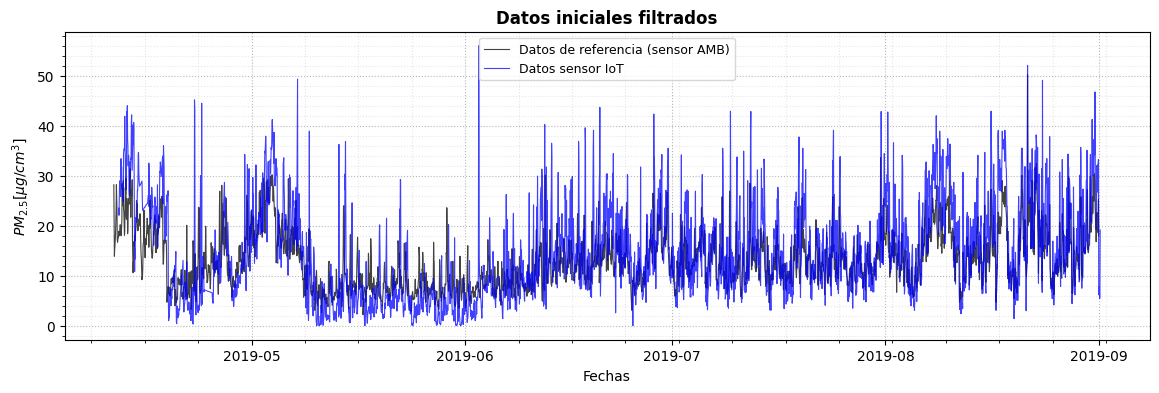

In [15]:
plt.figure(figsize = (14, 4))


plt.plot(data_Ref['Fecha'],data_Ref['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth = 0.8, color = "#2E2E2E", alpha = 0.9)
plt.plot(data_iot['Fecha'],data_iot['PM2.5'], label='Datos sensor IoT', linewidth = 0.8, color = "blue", alpha = 0.75)

# Configuración del gráfico:

plt.xlabel("Fechas")
plt.ylabel(r'$PM_{2.5}  [μg/cm^{3}]$')
plt.title("Datos iniciales filtrados", fontweight = 'bold')
plt.minorticks_on()
plt.legend(fontsize = 9)
plt.gca().set_axisbelow(True)
plt.grid(which='major', alpha=0.9, linestyle=':')
plt.grid(which='minor', alpha=0.3, linestyle=':')

#### **1.2 Ventanas y pasos**

In [16]:
from datetime import timedelta

In [17]:
# Removed redundant reset_index() calls

In [18]:
# DEFINICIÓN DE LOS VALORES DE LAS VENTANAS MÓVILES, PARA UN VALOR DE VENTANA Y DE PASO VARIABLE

def data_ventanas(data_iot, data_Ref, ventana_horas, paso_horas):
    # Asegurar datetime
    data_iot = data_iot.copy()
    data_Ref = data_Ref.copy()
    data_iot['Fecha'] = pd.to_datetime(data_iot['Fecha'])
    data_Ref['Fecha'] = pd.to_datetime(data_Ref['Fecha'])

    # Límites:
    liminf = max(data_iot['Fecha'].min(), data_Ref['Fecha'].min())
    limsup = min(data_iot['Fecha'].max(), data_Ref['Fecha'].max())

    resultados = []
    x_ = liminf

    while x_ <= limsup:
        # Se define el intervalo de la ventana [x_, x_ + ventana)
        ini = x_
        fin = x_ + timedelta(hours=ventana_horas)

        eps_j = ini + (fin - ini) / 2

        # Seleccionamos los valores dentro de esa ventana
        IoT_win = data_iot[(data_iot['Fecha'] >= ini) & (data_iot['Fecha'] < fin)]
        Ref_win = data_Ref[(data_Ref['Fecha'] >= ini) & (data_Ref['Fecha'] < fin)]

        # Promedios, tomamos a los valores que se seleccionaron de esa ventana y les encontramos promedio en su cantidad de PM2.5 para IoT y para AMB (ref)
        IoT_mean = IoT_win['PM2.5'].mean() if not IoT_win.empty else None
        Ref_mean = Ref_win['PM2.5'].mean() if not Ref_win.empty else None

        resultados.append({
            "Ventana_inicio": ini,
            "Ventana_fin": fin,
            "Eps_j": eps_j,
            "PM2.5_IoT": IoT_mean,
            "PM2.5_AMB": Ref_mean
        })

        # Avanzar al siguiente paso
        x_ += timedelta(hours=paso_horas)

    return pd.DataFrame(resultados)

In [19]:

df_1y1 = data_ventanas(data_iot, data_Ref, ventana_horas=1, paso_horas=1)

In [20]:
df_1y05 = data_ventanas(data_iot, data_Ref, ventana_horas=1, paso_horas=0.5)

In [21]:
df_1y1

,Ventana_inicio,Ventana_fin,Eps_j,PM2.5_IoT,PM2.5_AMB
0,2019-04-11 17:29:20.949,2019-04-11 18:29:20.949,2019-04-11 17:59:20.949,22.791667,18.9
1,2019-04-11 18:29:20.949,2019-04-11 19:29:20.949,2019-04-11 18:59:20.949,25.250000,18.0
2,2019-04-11 19:29:20.949,2019-04-11 20:29:20.949,2019-04-11 19:59:20.949,28.749998,18.4
3,2019-04-11 20:29:20.949,2019-04-11 21:29:20.949,2019-04-11 20:59:20.949,29.000000,19.3
4,2019-04-11 21:29:20.949,2019-04-11 22:29:20.949,2019-04-11 21:59:20.949,27.833334,20.2
...,...,...,...,...,...
3409,2019-08-31 18:29:20.949,2019-08-31 19:29:20.949,2019-08-31 18:59:20.949,26.833332,20.4
3410,2019-08-31 19:29:20.949,2019-08-31 20:29:20.949,2019-08-31 19:59:20.949,32.333336,18.7
3411,2019-08-31 20:29:20.949,2019-08-31 21:29:20.949,2019-08-31 20:59:20.949,32.416668,22.8
3412,2019-08-31 21:29:20.949,2019-08-31 22:29:20.949,2019-08-31 21:59:20.949,33.250000,25.2


In [22]:
df_1y05

,Ventana_inicio,Ventana_fin,Eps_j,PM2.5_IoT,PM2.5_AMB
0,2019-04-11 17:29:20.949,2019-04-11 18:29:20.949,2019-04-11 17:59:20.949,22.791667,18.9
1,2019-04-11 17:59:20.949,2019-04-11 18:59:20.949,2019-04-11 18:29:20.949,22.083334,18.9
2,2019-04-11 18:29:20.949,2019-04-11 19:29:20.949,2019-04-11 18:59:20.949,25.250000,18.0
3,2019-04-11 18:59:20.949,2019-04-11 19:59:20.949,2019-04-11 19:29:20.949,25.250000,18.0
4,2019-04-11 19:29:20.949,2019-04-11 20:29:20.949,2019-04-11 19:59:20.949,28.749998,18.4
...,...,...,...,...,...
6823,2019-08-31 20:59:20.949,2019-08-31 21:59:20.949,2019-08-31 21:29:20.949,32.416668,22.8
6824,2019-08-31 21:29:20.949,2019-08-31 22:29:20.949,2019-08-31 21:59:20.949,33.250000,25.2
6825,2019-08-31 21:59:20.949,2019-08-31 22:59:20.949,2019-08-31 22:29:20.949,33.250000,25.2
6826,2019-08-31 22:29:20.949,2019-08-31 23:29:20.949,2019-08-31 22:59:20.949,6.916667,18.0


In [23]:
df_4y2 = data_ventanas(data_iot, data_Ref, ventana_horas=4, paso_horas=2)

#### **1.3 Error euclídeo, RMSE y RMSE relativo**

In [24]:
# Ahora bien, ya con cada uno de los valores de PM2.5 IoT emparejado con un PM2.5 AMB, podemos prodecer a calcular el error para cada dataset que así empereje los datos:

# ERROR EUCLÍDEO (μ/m^3):
### Este tipo de error acumula al error de todas las ventanas. Esto es, entre mayor el número de ventanas se obtendría un mayor error euclídeo. Por ello, también se define al RMSE
### ()
def error_euclideo(df):
    dif = (df["PM2.5_IoT"] - df["PM2.5_AMB"]).dropna()
    return np.sqrt((dif**2).sum())

# ERROR CUADRÁTICO MEDIO (μ/m^3)
def rmse(df):
    dif = df["PM2.5_IoT"] - df["PM2.5_AMB"]
    dif = dif.dropna()  # quitar NaN
    return np.sqrt((dif**2).mean())

# RMSE RELATIVO (%):
def rmse_relativo(df):
    # Diferencia
    dif = df["PM2.5_IoT"] - df["PM2.5_AMB"]
    dif = dif.dropna()

    # RMSE absoluto
    rmse = np.sqrt((dif**2).mean())

    # Promedio de la referencia
    media_ref = df["PM2.5_AMB"].mean()

    # RMSE relativo en %
    return (rmse / media_ref) * 100

In [25]:
error_euclideo(df_1y1), rmse(df_1y1), rmse_relativo(df_1y1)

(np.float64(410.45091772423854),
 np.float64(7.122407099069452),
 np.float64(54.89613117273628))

In [26]:
rmse(df_1y05), rmse_relativo(df_1y05)

(np.float64(7.121078062149118), np.float64(54.885887587372885))

In [27]:
# GANADOR, 4Y2:

error_euclideo(df_4y2), rmse(df_4y2), rmse_relativo(df_4y2)

(np.float64(228.5889447052033),
 np.float64(5.576999195325903),
 np.float64(42.98165010023315))

#### **1.4 Prueba para estimar mejor ventana y mejor paso**
Ahora, probaremos con distintos valores de ventana y de paso y se les calculará el RMSE y el RMSE relativo para estimar la mejor elección

In [28]:
ventanas = [1, 4, 8, 12, 24]   # en horas
pasos    = [0.5, 1, 2, 4, 8, 12, 24] # en horas

resultados = []

for v in ventanas:
    for p in pasos:
        if v > p:
            # Medir tiempo de ejecución
            t0 = time.time()

            # Construir dataset de ventanas
            df_v = data_ventanas(data_IoT, data_ref, ventana_horas=v, paso_horas=p)

            # Calcular errores
            error = error_euclideo(df_v)
            rmse_val = rmse(df_v)
            rmse_rel = rmse_relativo(df_v)

            # Tiempo final
            t1 = time.time()
            tiempo = t1 - t0   # en segundos

            resultados.append({
                "Ventana (h)": v,
                "Paso (h)": p,
                "Error (µg/m³)": error.round(2),
                "RMSE (µg/m³)": rmse_val.round(2),
                "RMSE_rel (%)": rmse_rel.round(2),
                "Tiempo cálculo (s)": round(tiempo, 2)
            })

# Convertir a DataFrame
tabla_errores = pd.DataFrame(resultados)

tabla_errores

,Ventana (h),Paso (h),Error (µg/m³),RMSE (µg/m³),RMSE_rel (%),Tiempo cálculo (s)
0,1,0.5,637.38,7.33,45.96,14.71
1,4,0.5,512.49,5.84,36.58,13.85
2,4,1.0,354.85,5.72,35.82,6.96
3,4,2.0,250.20,5.70,35.70,3.69
4,8,0.5,425.98,4.82,30.20,13.76
5,8,1.0,296.19,4.74,29.69,6.78
6,8,2.0,209.70,4.75,29.71,3.66
7,8,4.0,147.92,4.73,29.64,1.63
8,12,0.5,387.02,4.36,27.27,13.63
9,12,1.0,270.95,4.32,27.00,7.57


### **2. Calibración del sensor IoT**

#### **2.1 Gráfico de datos IoT vs datos referencia (AMB)**

In [29]:
# En está sección, haremos una función que grafique para un data set (pues será útil si se hace el gráfico para diferentes ventanas móviles) cómo lucen los datos IoT vs los de AMB.
def graph_iotVSamb(df):
  x = df["PM2.5_IoT"]
  y = df["PM2.5_AMB"]

  # Estimamos el valor de la ventana y el paso a partir de cómo está construido el data frame para poder añadirlo al gráfico:
  ventana = (df["Ventana_fin"] - df["Ventana_inicio"]).unique()[0]
  paso = df["Ventana_inicio"].diff().dropna().unique()[0]

  ventana_h = ventana.total_seconds() / 3600
  paso_h = paso.total_seconds() / 3600

  plt.figure(figsize = (5, 5))
  plt.scatter(x, y,
              s = 30, color = 'blue', alpha = 0.4, label = f'Ventanas = {ventana_h}H, \nPasos ={paso_h}H')

  plt.xlabel(r"$PM_{2.5}$ Sensor IoT (Bajo costo) [µg/m³]")
  plt.ylabel(r"$PM_{2.5}$ Sensor AMB [µg/m³]")
  plt.minorticks_on()
  plt.gca().set_axisbelow(True)   # Para colorcar la cuadrícula por debajo de todo
  plt.legend(fontsize = 9, loc = 'lower right', framealpha = 0.4)
  plt.grid(which='major', alpha=0.9, linestyle=':')
  plt.grid(which='minor', alpha=0.3, linestyle=':')

In [30]:
df_8y8 = data_ventanas(data_iot, data_Ref, ventana_horas=8, paso_horas=0.5)

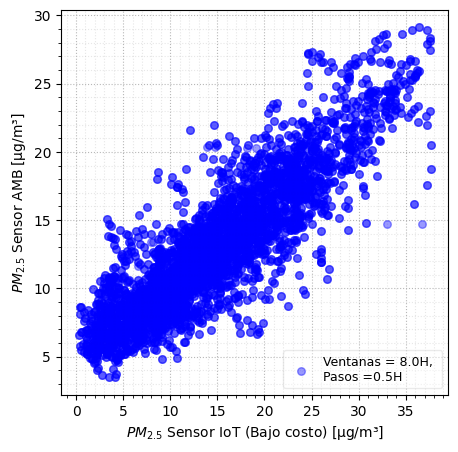

In [31]:
graph_iotVSamb(df_8y8)

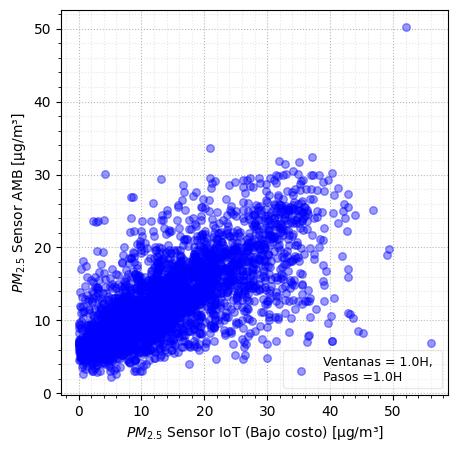

In [32]:
graph_iotVSamb(df_1y1)

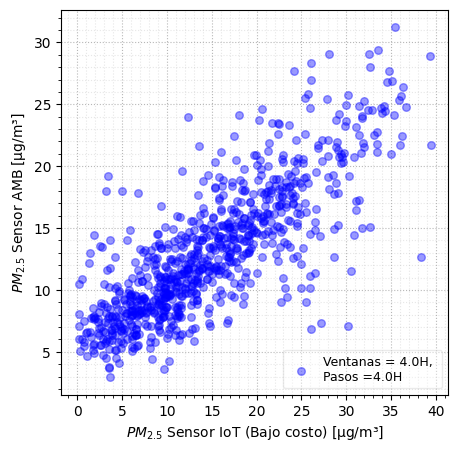

In [33]:
graph_iotVSamb(data_ventanas(data_iot, data_Ref, ventana_horas=4, paso_horas=4))

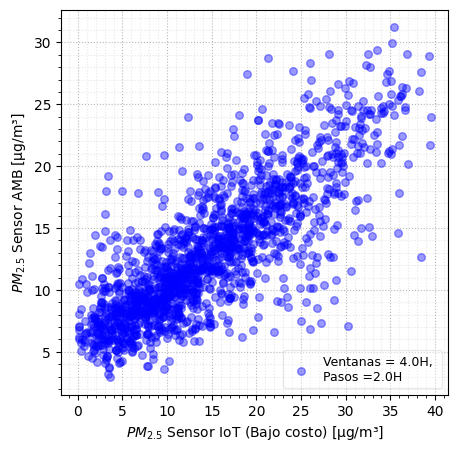

In [34]:
graph_iotVSamb(data_ventanas(data_iot, data_Ref, ventana_horas=4, paso_horas=2))

#### **2.2 Regresión lineal datos IoT y AMB. Calibrado**

Para esta sección se pocrederá a encontrar una función que así encuentre a los coeficientes m y b tales que se realice una regresión por el método de mínimos cuadrados. De esta manera, se espera encontrar una forma de calibrar los datos detectados por el sensor de bajo costo (IoT) y, en consecuencia, minimizar el error entre dichos datos respectos a los tomados por el sensor de referencia (AMB)

In [35]:
def recta_calibrado(df):
  # En primer lugar, depuramos los datos Nan:
  df_cleaned = df.dropna(subset=["PM2.5_IoT", "PM2.5_AMB"])

  X = df_cleaned["PM2.5_IoT"].to_numpy()
  Y = df_cleaned["PM2.5_AMB"].to_numpy()

  # Fórmula de mínimos cuadrados sin intercepto
  m = np.sum(X * Y) / np.sum(X**2)

  return m

In [36]:
recta_calibrado(df_8y8)

np.float64(0.806606384941558)

In [37]:
#ERROR, pero generalizado:
def RMSE_(df, dato):
    dif = df[dato] - df["PM2.5_AMB"]
    dif = dif.dropna()  # quitar NaN
    return np.sqrt((dif**2).mean())

def RMSE_rel_(df, dato):
    # Diferencia
    dif = df[dato] - df["PM2.5_AMB"]
    dif = dif.dropna()

    # RMSE absoluto
    rmse = np.sqrt((dif**2).mean())

    # Promedio de la referencia
    media_ref = df["PM2.5_AMB"].mean()

    # RMSE relativo en %
    return (rmse / media_ref) * 100

In [38]:
# Ahora, se procede a hacer una función que grafique a la regresión y a cómo lucen los datos normalizados
def graph_calibrado(df):
  # Creamos una copia:

  df = df.copy()

  # GRÁFICO REGRESIÓN
    ### PARTÍCULAS:
  x = df["PM2.5_IoT"]
  y = df["PM2.5_AMB"]

  ventana = (df["Ventana_fin"] - df["Ventana_inicio"]).unique()[0]
  paso = df["Ventana_inicio"].diff().dropna().unique()[0]

  ventana_h = ventana.total_seconds() / 3600
  paso_h = paso.total_seconds() / 3600

  m1 = recta_calibrado(df)

  # Estimamos el máximo en x (correspondiente a los datos de las párticulas del sensor  IoT) para poder crear el plot
  maxx = df["PM2.5_IoT"].max() + 5

  ejex = np.linspace(0, maxx, 100)

    ### DATOS:
  plt.figure(figsize = (5, 5))
  plt.scatter(x, y,
              s = 30, color = 'blue', alpha = 0.4, label = f'Ventanas = {ventana_h}H, \nPasos ={paso_h}H')

    ### RECTA
  plt.plot(ejex, m1*ejex,
           color = 'red', linewidth = 2, label = f'CALIBRADO: \n{m1.round(3)}'r'*$PM_{2.5}IoT$')

  plt.xlabel(r"$PM_{2.5}$ Sensor IoT (Bajo costo) [µg/m³]")
  plt.ylabel(r"$PM_{2.5}$ Sensor AMB [µg/m³]")
  plt.minorticks_on()
  plt.gca().set_axisbelow(True)   # Para colorcar la cuadrícula por debajo de todo
  plt.legend(fontsize = 9, loc = 'upper left', framealpha = 0.4)
  plt.grid(which='major', alpha=0.9, linestyle=':')
  plt.grid(which='minor', alpha=0.3, linestyle=':')

  plt.show()


  # GRÁFICO CALIBRADO:
  ##### En primer lugar, tenemos que hacer una columna en df en la cual se guarden los resultados calibrados:
  df['PM2.5_fit'] = m1*df['PM2.5_IoT']
  xfit = df['PM2.5_fit']
  eps_j = df['Eps_j']     #Esto es, el valor "representativo" (medio) de cada pareja nueva de datos

  plt.figure(figsize = (14, 4))

  plt.plot(data_Ref['Fecha'],data_Ref['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth = 0.8, color = "#2E2E2E", alpha = 0.5)
  plt.plot(eps_j, xfit, linewidth = 1.5, color = "blue", alpha = 0.75, label = f'Datos sensor IoT calibrados, xfit = \n{m1.round(3)}'r'*$PM_{2.5}IoT$')


  # ERROR GENERAL:
  err = RMSE_(df, 'PM2.5_fit')
  plt.text(df['Eps_j'].min(), 38, f"Error(RMSE) AMB y IoT (calibrado): {err.round(3)} $[\mu g /m^3]$", fontsize=10, ha='left', va='center')

  ## Configuración del gráfico:

  plt.xlabel("Fechas")
  plt.ylabel(r'$PM_{2.5}  [μg/cm^{3}]$')
  plt.minorticks_on()
  plt.legend(fontsize = 9, loc = "upper left")
  plt.gca().set_axisbelow(True)
  plt.grid(which='major', alpha=0.9, linestyle=':')
  plt.grid(which='minor', alpha=0.3, linestyle=':')
  plt.show()


<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1562543114.py:59: SyntaxWarning: invalid escape sequence '\m'
  plt.text(df['Eps_j'].min(), 38, f"Error(RMSE) AMB y IoT (calibrado): {err.round(3)} $[\mu g /m^3]$", fontsize=10, ha='left', va='center')


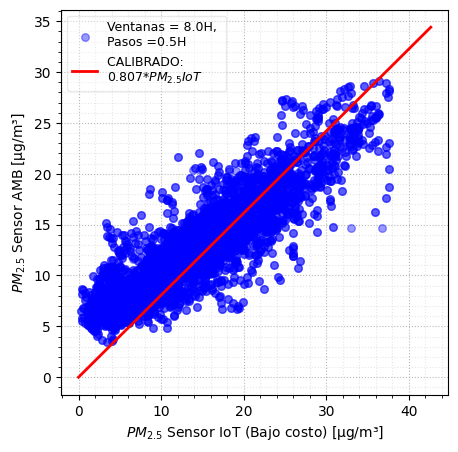

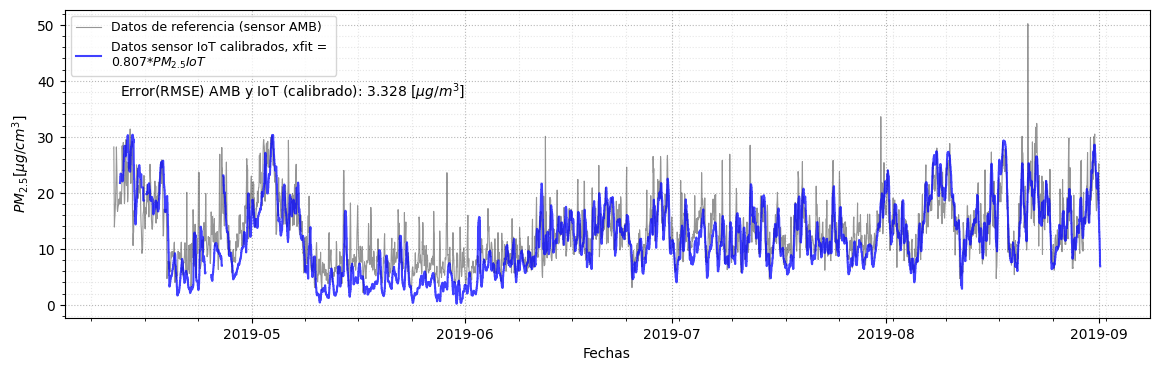

In [39]:
graph_calibrado(df_8y8)

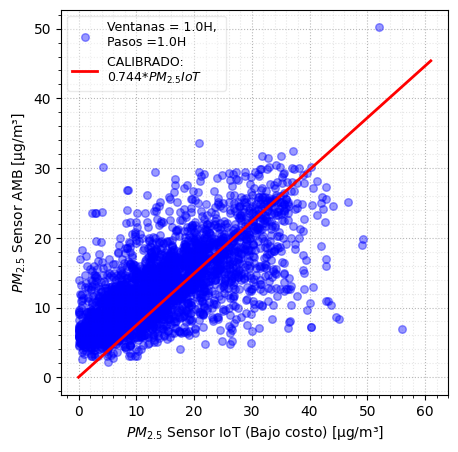

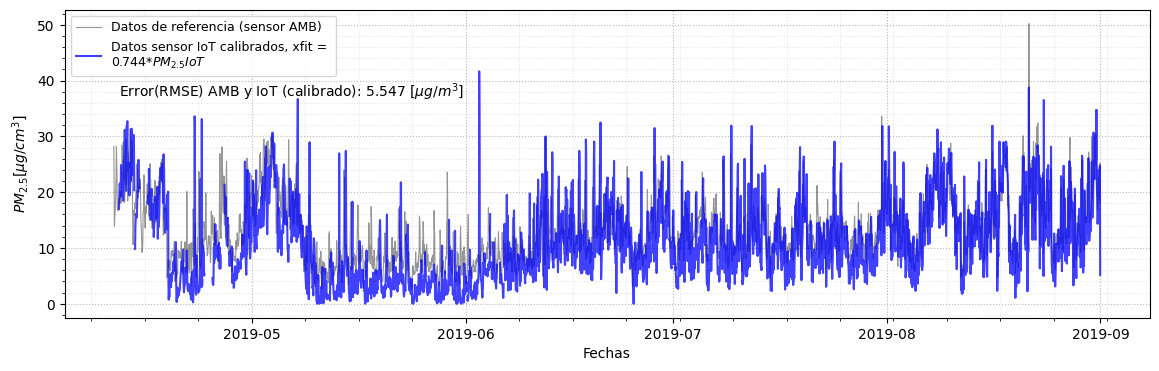

In [40]:
graph_calibrado(df_1y1)

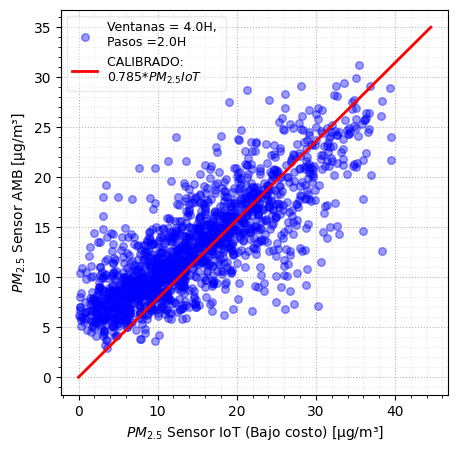

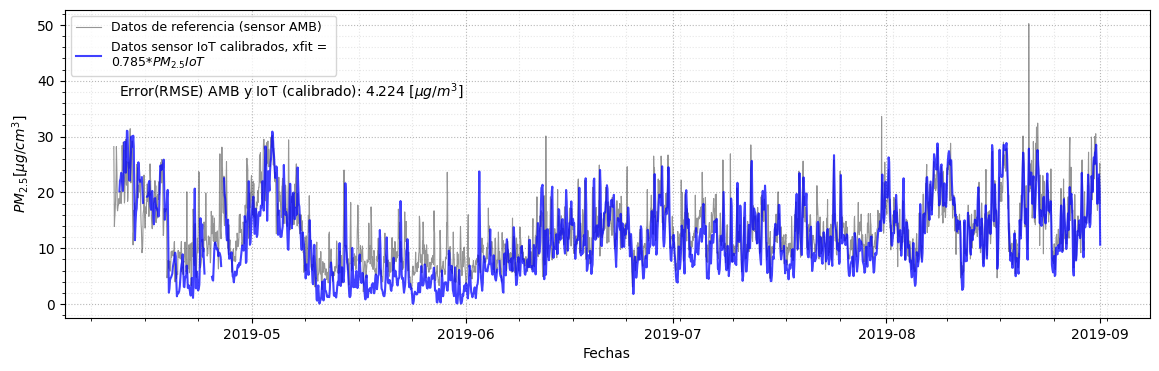

In [41]:
graph_calibrado(df_4y2)

### **3. Alcance, predictibilidad y tolerancia**

En esta sección aparte de considerar la complejidad computacional y el error *acumulado* entre los datos del sensor de mala calidad (IoT) y el sensor de referencia (AMB), se mirará el **alcance** de cada aproximación en consideración del número de ventana y del número de pasos. Esto será útil en cuanto ver el nivel de predictibilidad con base en los datos ya planteados, suponiendo que algunos subintervalos conformarían "datos futuros" y, de esta manera, poder ver el error por cada subintervalo anterior y la calidad de cada regresión a nivel local.

In [55]:
# tenemos que tomar n 'partes' del dataframe. k son la cantidad de intervalos sobre los cuales se mira el error de los datos, esto es, sobre los cuales vemos que tan predecible es nuestro modelo.

def  predic_df(df, k, n, tol):
  # En primer lugar, tomamos el segmento de los datos del dataframe sobre el cual se hará la regresión
  df = df.copy()


  liminf = df['Ventana_inicio'].min()
  limsup = df['Ventana_fin'].max()

  l = (limsup - liminf) / n # El tamaño de la ventana

  # INTERVALOS DE LA NUEVA REGRESIÓN:
  ini = liminf
  fin = liminf + l

  # Definimos un nuevo dataset pero que cuente solo los datos dentro del intervalo [ini, fin], y a él le aplicaremos la regresión
  df_intervalo = df[(df['Ventana_inicio'] >= ini) & (df['Ventana_fin'] <= fin)].copy()

  # Para obtener el dato calibrado, usamos la función de antes pero para dicho dataset:

  m1 = recta_calibrado(df_intervalo)

  # ERRORES:
  l_test = (limsup - liminf) / k # el ancho de cada intervalo sobre el cual miraremos el error (esto es, errores locales que tienen en cuenta a varios valores de ventana)
  errores = []

  for j in range(k):
    ## En primer lugar, evaluamos los intervalos sobre los cuales se evalúa el error, esto es, cada intervalo es [fin, fin +k], [fin + k, fin + 2k], ...
    ini_test = liminf + j*l_test
    fin_test = ini_test + l_test


    #k es el número del intervalo sobre el que estamos evaluando, a este intervalo de los datos le tenemos que calcular el error. Entonces, definimos un nuevo data set pero que esté dentro del intervalo:
    df_error = df[(df['Ventana_inicio'] >= ini_test) & (df['Ventana_fin'] <= fin_test)].copy()

    if not df_error.empty:
    # Predicción usando la pendiente entrenada
      df_error["PM2.5_fit"] = m1 * df_error["PM2.5_IoT"]

    # Error local (ejemplo RMSE)
      dif = df_error["PM2.5_fit"] - df_error["PM2.5_AMB"]
      rmse_val = np.sqrt((dif**2).mean())
      errores.append(rmse_val)

      if df_error.empty:
        errores.append(np.nan)

    # Se verifica si en todos los intervalos se cumple la tolerancia
    valido = True

  if not errores:   # si la lista está vacía, entonces no es válido
      valido = False
  else:
      for err in errores:
          if err > tol:   # si algún error excede la tolerancia
              valido = False
              break       # no hace falta seguir revisando
  return {"pendiente": m1, "errores": errores, "valido": valido}

In [71]:
predic_df(df_4y2, n = 2, k = 200, tol = 10)

r = predic_df(df_4y2, n = 2, k = 10, tol = 10)["errores"]
max(r), min(r)

(np.float64(5.5080956056109445), np.float64(2.0150514526781467))

In [69]:
predic_df(df_4y2, n = 2, k = 200, tol = 10)

{'pendiente': np.float64(0.7770595700527378),
 'errores': [np.float64(3.492403834910564),
  np.float64(6.029811425878488),
  np.float64(5.672024955141238),
  np.float64(4.558019666764126),
  np.float64(7.71749953515948),
  np.float64(1.2372920230867093),
  np.float64(4.178746724908648),
  np.float64(2.4409757987302765),
  np.float64(2.0277911813505223),
  np.float64(6.63255277724394),
  np.float64(3.7707175240289064),
  np.float64(2.4456335755904055),
  np.float64(4.670567980594279),
  np.float64(4.170402041063752),
  np.float64(5.0938106234431295),
  np.float64(6.145183606209642),
  np.float64(9.557497103584662),
  np.float64(5.20141511632092),
  np.float64(nan),
  np.float64(4.48671151361076),
  np.float64(7.270847276971632),
  np.float64(3.05354495123259),
  np.float64(2.466412092931928),
  np.float64(3.7800599450675807),
  np.float64(6.033002684794416),
  np.float64(4.375213717378907),
  np.float64(6.025811502057145),
  np.float64(2.5636793602523804),
  np.float64(6.555943465054477

In [79]:
def graph_predic(df, k, n, tol):
  # extraemos el valor de la pendiente de la regresión para dicho valor:
  m1 = predic_df(df, k, n, tol)["pendiente"]

  df = df.copy()

  # GRÁFICO DE LOS DATOS REGRESIÓN:
  df['PM2.5_fit'] = m1*df['PM2.5_IoT']      # Note que acá la pendiente sale de la función de predicción declarada anteriormente
  xfit = df['PM2.5_fit']
  eps_j = df['Eps_j']     #Esto es, el valor "representativo" (medio) de cada pareja nueva de datos

  plt.figure(figsize = (14, 4))

  plt.plot(data_Ref['Fecha'],data_Ref['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth = 0.8, color = "#2E2E2E", alpha = 0.5)
  plt.plot(eps_j, xfit, label = f'Datos sensor IoT calibrados, xfit = \n{m1.round(3)}'r'*$PM_{2.5}IoT$', linewidth = 1.5, color = "blue", alpha = 0.75)

  # RECTA que indica el punto sobre hasta el cual se hizo la regresión:

  liminf = df['Ventana_inicio'].min()
  limsup = df['Ventana_fin'].max()
  l = (limsup - liminf) / n
  fin = liminf + l

  # Línea vertical punteada
  plt.axvline(x=fin, color="red", linestyle="--", linewidth=2,
              label=f"Regresión hasta {fin.strftime('%Y-%m-%d %H:%M')}, n = {n}")


  # ERROR GENERAL: (Dado que ya miramos si cada intervalo local cumple o no con una cierta tolerancia), vemos, de nuevo, cómo funciona a nivel global
  err = RMSE_(df, 'PM2.5_fit')
  plt.text(df['Eps_j'].max() + pd.Timedelta(days = 10), 0, (f"Error(RMSE) AMB y IoT (calibrado): {err.round(3)} $[\mu g /m^3]$"), fontsize=9, ha='right', va='center')

  plt.xlabel("Fechas")
  plt.ylabel(r'$PM_{2.5}  [μg/cm^{3}]$')
  plt.minorticks_on()
  plt.legend(fontsize = 9, loc = "upper right")
  plt.gca().set_axisbelow(True)
  plt.grid(which='major', alpha=0.9, linestyle=':')
  plt.grid(which='minor', alpha=0.3, linestyle=':')
  plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-686684429.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.text(df['Eps_j'].max() + pd.Timedelta(days = 10), 0, (f"Error(RMSE) AMB y IoT (calibrado): {err.round(3)} $[\mu g /m^3]$"), fontsize=9, ha='right', va='center')


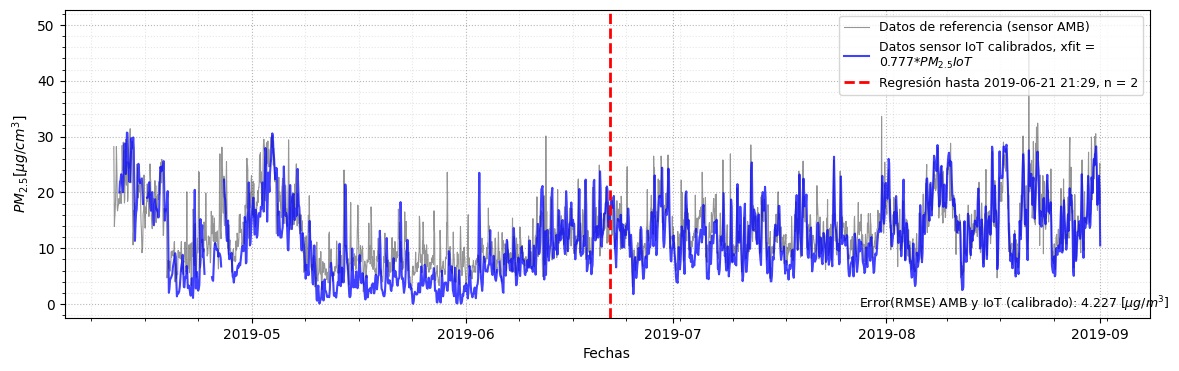

In [80]:
graph_predic(df_4y2, n = 2, k = 100, tol = 10)

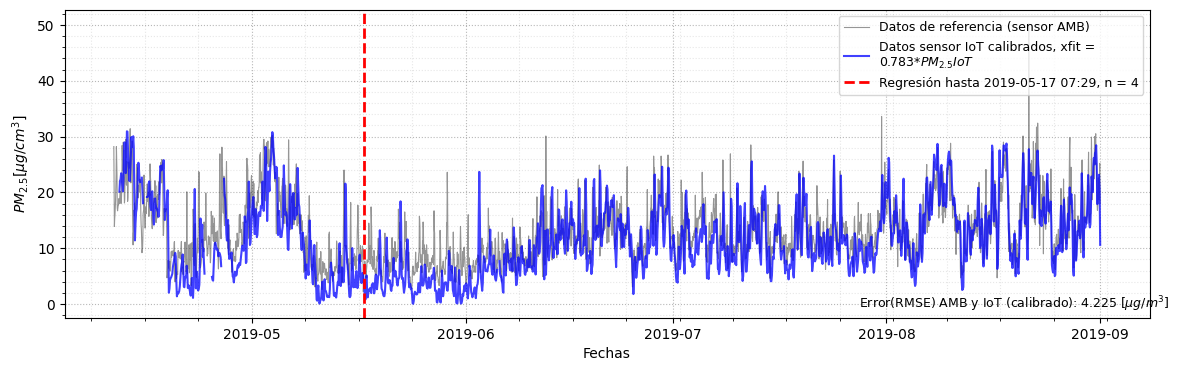

In [81]:
graph_predic(df_4y2, n = 4, k = 100, tol = 10)

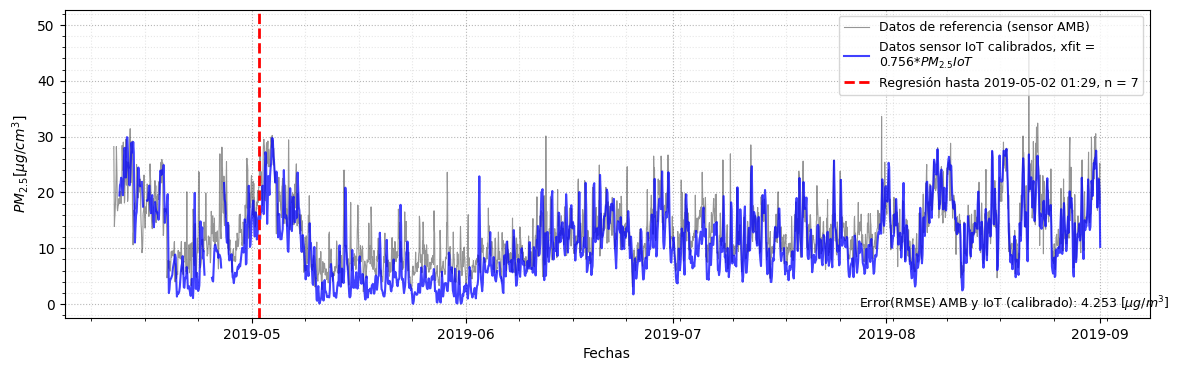

In [82]:
graph_predic(df_4y2, n =7, k = 100, tol = 10)

In [48]:
def graph_predic_k(df, k, n, tol):
  # extraemos el valor de la pendiente de la regresión para dicho valor:
  m1 = predic_df(df, k, n, tol)["pendiente"]

  df = df.copy()

  # GRÁFICO DE LOS DATOS REGRESIÓN:
  df['PM2.5_fit'] = m1*df['PM2.5_IoT']      # Note que acá la pendiente sale de la función de predicción declarada anteriormente
  xfit = df['PM2.5_fit']
  eps_j = df['Eps_j']     #Esto es, el valor "representativo" (medio) de cada pareja nueva de datos

  plt.figure(figsize = (14, 4))

  plt.plot(data_Ref['Fecha'],data_Ref['PM2.5'], label='Datos de referencia (sensor AMB)', linewidth = 0.8, color = "#2E2E2E", alpha = 0.5)
  plt.plot(eps_j, xfit, label='Datos sensor IoT', linewidth = 1.5, color = "blue", alpha = 0.75)

  # RECTA que indica el punto sobre hasta el cual se hizo la regresión:

  liminf = df['Ventana_inicio'].min()
  limsup = df['Ventana_fin'].max()
  l = (limsup - liminf) / n
  fin = liminf + l

  # Línea vertical punteada
  plt.axvline(x=fin, color="red", linestyle="--", linewidth=2,
              label=f"Regresión hasta {fin.strftime('%Y-%m-%d %H:%M')}")
    # Líneas verticales rojas para cada k
  l1 = (limsup - liminf) / k

  for j in range(1, k+1):
    fin = liminf + j*l1
    plt.axvline(x=fin, color="green", linestyle="-.", linewidth=1,
                alpha=0.7 if j < k else 1.0,  # más opaca la última
                label=f"Partición {j}/{k}" if j in (1, k) else None)

  plt.xlabel("Fechas")
  plt.ylabel(r'$PM_{2.5}  [μg/cm^{3}]$')
  plt.minorticks_on()
  plt.gca().set_axisbelow(True)
  plt.show()

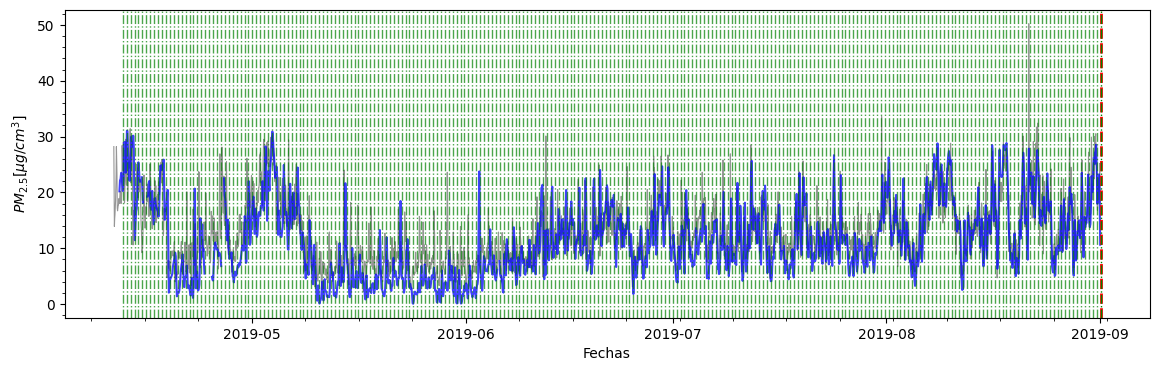

In [90]:
graph_predic_k(df_4y2, n = 1, k = 250, tol = 10)

Estimación del error de forma cuando se usan todos los datos para la regresión (n=1)

#### **3.2 Estimación del menor número de datos para el cual es posible hacer una 'buena' calibración**

Para esta sección, se buscará el valor mínimo de $n$ partes sobre las que se puede dividir a los datos y que dicha estimación sea válida de forma local. La forma de establecer dicha validez se hará mediante el establecimiento de una tolerancia fija de $10 [\mu g /m ^3]$ y de un número de intervalos $k = 100$ (graficados anteriormente) para sobre ellos estimar el RMSE de la regresión con los datos AMB, y luego ver si dicho valor sobrepasa o no a la tolerancia.

In [91]:
k = 250
tol = 10
df = df_4y2
n = 10

salida = False

for i in range(2,n):
    validez = predic_df(df, k, i, tol)["valido"]
    while salida == False:
      if validez == False:
        print("El valor máximo de particiones fue de:", i + 2) # Se suman dos pues python empieza a contar al primer elemento como 0, y en este caso, iniciamos desde n = 2.
        salida = True

# Observaciones: el número de k afecta MUCHO, el valor. DISCUTIR ESTO

El valor máximo de particiones fue de: 4


In [95]:
r = predic_df(df_4y2, n = 4, k = 250, tol = 10)['errores']
contador = 0
for i in range(len(r)):
  if r[i] > 10:
    contador +=1

print(contador)


4


In [96]:
predic_df(df_4y2, n = 4, k = 250, tol = 10)['errores']

[np.float64(2.8522007851468354),
 np.float64(5.436533346877598),
 np.float64(6.119711059034604),
 np.float64(11.152130837104366),
 np.float64(4.504712831264002),
 np.float64(1.1752983579027447),
 np.float64(4.4436550646597865),
 np.float64(2.7228112639977633),
 np.float64(3.734421561016034),
 np.float64(0.9987855208246716),
 np.float64(2.140139469186827),
 np.float64(7.325799679685997),
 np.float64(8.832872648064047),
 np.float64(3.3726627428024134),
 np.float64(2.573255777870854),
 np.float64(5.427007456157351),
 np.float64(4.289916034665449),
 np.float64(3.65591061267036),
 np.float64(5.6187937797963015),
 np.float64(5.661348358470721),
 np.float64(11.114455248416357),
 np.float64(4.493602865658446),
 np.float64(nan),
 np.float64(9.165379569539837),
 np.float64(3.0237229556975773),
 np.float64(7.406153761895356),
 np.float64(4.664052515461517),
 np.float64(5.361019484430678),
 np.float64(1.3975294533749638),
 np.float64(3.5552488326103173),
 np.float64(5.620872169763072),
 np.float64